This notebook explains how to extract the data from the predictor raster variables to the point layer with landslide presence/absence points

In [1]:
from pyspatialml import Raster
import os
import matplotlib.pyplot as plt
import geopandas
import pandas as pd
import seaborn as sn
import rasterio.plot
import numpy as np

Setting up the directiry path

In [2]:
os.chdir('C:/Flood Data/Flood Factors/Resample_Factors')

Choosing all the predictors

In [3]:
predictors = ['Aspect.tif', 'Elevation.tif',  'Slope.tif', 'Profile_curvature.tif', 'Plan_curvature.tif', 'Mean_RX1day_Rainfall.tif','Mean_RX3day_Rainfall.tif', 'Mean_Annual_Rainfall.tif', 'NDVI.tif', 'LULC.tif', 'SPI.tif', 'TWI.tif', 'Soil.tif','Geology.tif','NDWI.tif','Distance_from_streams.tif','Drainage_Density.tif']

Making a raster stack of all the predictors. The predictors have the same extent, projection and resolution


In [4]:
stack = Raster(predictors)

Checking the bands in our stack


In [5]:
stack.names

dict_keys(['Aspect', 'Elevation', 'Slope', 'Profile_curvature', 'Plan_curvature', 'Mean_RX1day_Rainfall', 'Mean_RX3day_Rainfall', 'Mean_Annual_Rainfall', 'NDVI', 'LULC', 'SPI', 'TWI', 'Soil', 'Geology', 'NDWI', 'Distance_from_streams', 'Drainage_Density'])

Reading the shapefile with landslide (centroids)/nonlandslide (randomly created) points and showing the first five rows

In [6]:
training_pt = geopandas.read_file('C:/Flood Data/Final_Inventory.shp')
training_pt.head(5)

,CID,Class,ID,Lon,Lat,geometry
0,0,0,0,0.0,0.0,POINT (600190.808 3621951.976)
1,0,0,0,0.0,0.0,POINT (589077.507 3613965.104)
2,0,0,0,0.0,0.0,POINT (641026.804 3611555.156)
3,0,0,0,0.0,0.0,POINT (611967.698 3639338.296)
4,0,0,0,0.0,0.0,POINT (624180.513 3582972.009)


Plotting the landslide/non-landslide points on the background of the DEM


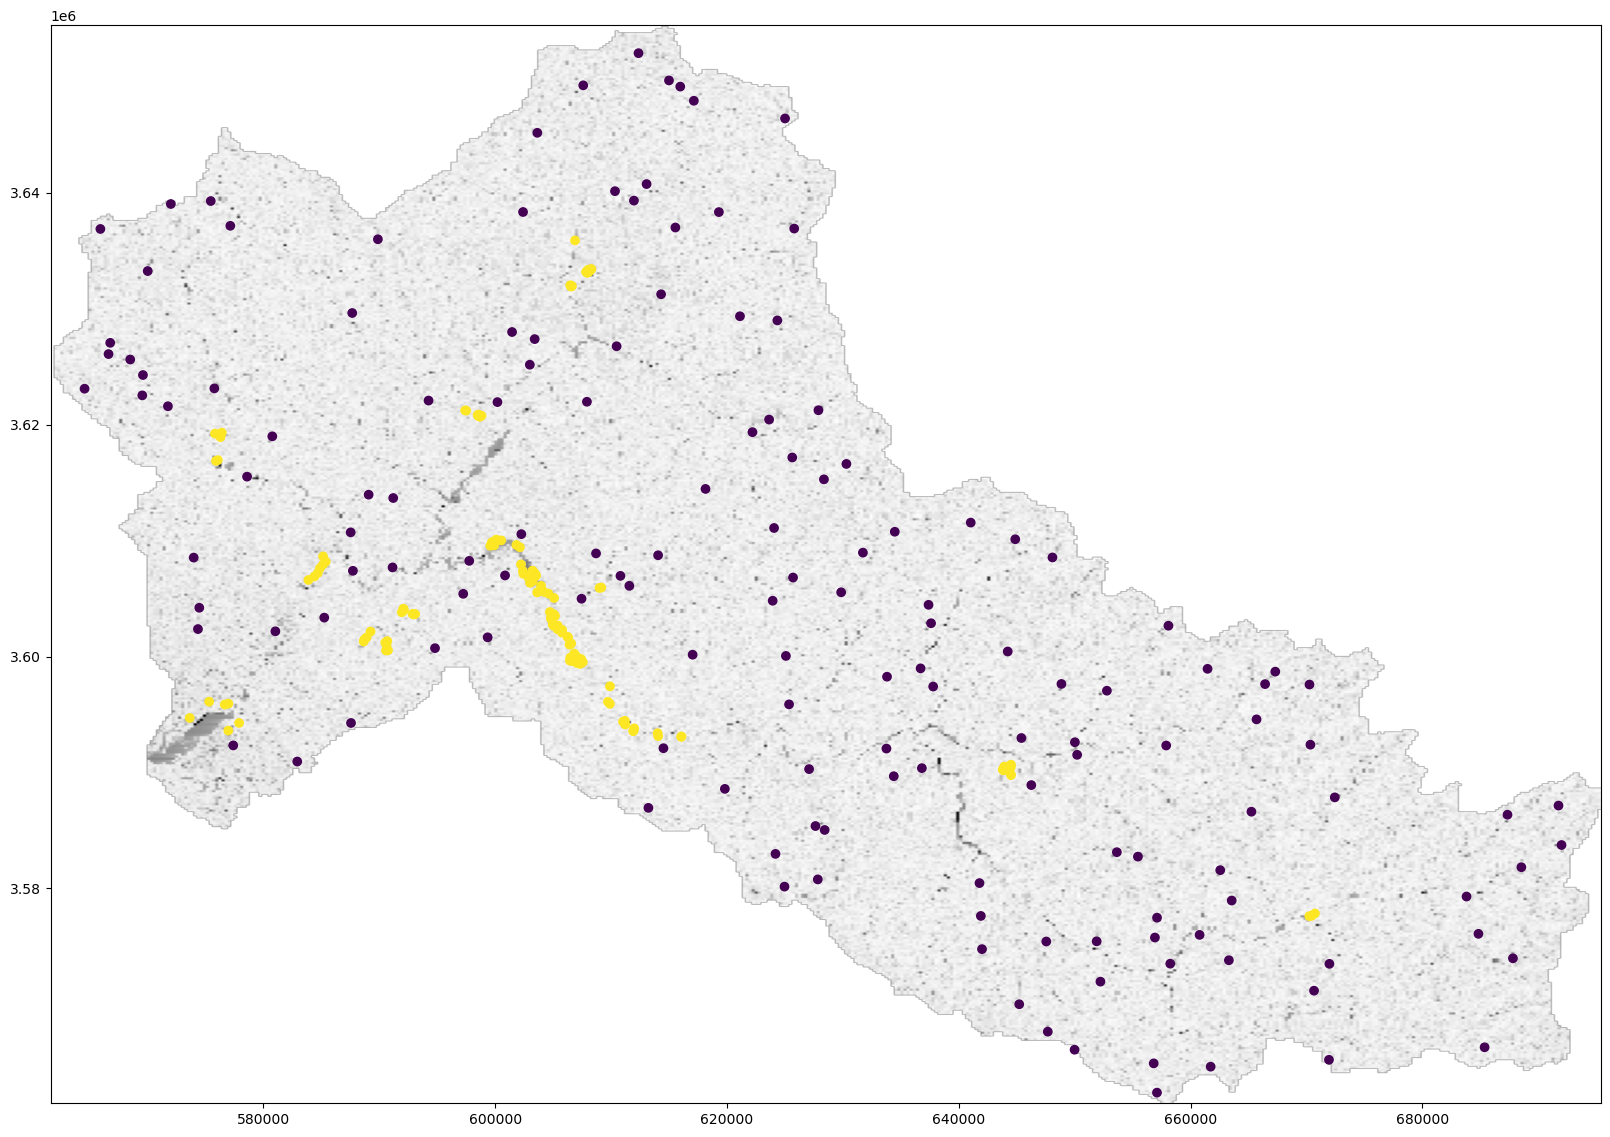

In [7]:
fig, ax = plt.subplots(figsize=(20, 20))
stack.TWI.plot(ax=ax, cmap='Greys')
training_pt.plot(column="Class", ax=ax)
#plt.savefig(r'figure1.png', bbox_inches='tight', dpi=1300)
plt.show()

Extracting the predictor features from the raster stack to our points


In [8]:
df_points = stack.extract_vector(training_pt)

Showing the first five rows


In [9]:
df_points.head(5)

,,Aspect,Elevation,Slope,Profile_curvature,Plan_curvature,Mean_RX1day_Rainfall,Mean_RX3day_Rainfall,Mean_Annual_Rainfall,NDVI,LULC,SPI,TWI,Soil,Geology,NDWI,Distance_from_streams,Drainage_Density,geometry
pixel_idx,geometry_idx,,,,,,,,,,,,,,,,,,
0,0,288.434937,1676.0,7.209121,-1.024000,0.256000,73.709358,127.795547,1459.744751,0.280242,17.0,0.496815,4.593312,2.0,9.0,-0.417748,372.050568,0.472717,POINT (600190.808 3621951.976)
1,1,234.865814,1697.0,44.725231,0.828993,-1.731007,73.811371,128.454819,1444.912109,0.186464,16.0,5.206606,5.174378,2.0,7.0,-0.446055,2353.054443,0.187682,POINT (589077.507 3613965.104)
2,2,60.592812,3803.0,32.266174,-0.827077,0.452923,81.329865,139.315689,1692.825928,0.092385,9.0,4.428362,4.371922,1.0,9.0,-0.523274,744.101135,0.318078,POINT (641026.804 3611555.156)
3,3,338.198578,1899.0,37.013485,-0.640000,0.640000,80.411331,137.253937,1597.987915,0.204164,17.0,5.807874,2.808194,2.0,16.0,-0.768516,372.050568,0.403678,POINT (611967.698 3639338.296)
4,4,354.093872,4167.0,49.387146,-0.680899,-0.040899,96.287956,164.629257,1899.889404,0.012031,20.0,3.683581,3.470599,1.0,14.0,0.049714,1663.860718,0.276737,POINT (624180.513 3582972.009)


Merging the data frame back with the class

In [10]:
df_points = df_points.merge(
    right=training_pt.loc[:, ["Class"]],
    left_on="geometry_idx",
    right_on="index",
    right_index=True
)

In [11]:
#df_points.drop(columns=['geometry','Class_x','Class_y'])
df_points.head(5)

,,Aspect,Elevation,Slope,Profile_curvature,Plan_curvature,Mean_RX1day_Rainfall,Mean_RX3day_Rainfall,Mean_Annual_Rainfall,NDVI,LULC,SPI,TWI,Soil,Geology,NDWI,Distance_from_streams,Drainage_Density,geometry,Class
pixel_idx,geometry_idx,,,,,,,,,,,,,,,,,,,
0,0,288.434937,1676.0,7.209121,-1.024000,0.256000,73.709358,127.795547,1459.744751,0.280242,17.0,0.496815,4.593312,2.0,9.0,-0.417748,372.050568,0.472717,POINT (600190.808 3621951.976),0
1,1,234.865814,1697.0,44.725231,0.828993,-1.731007,73.811371,128.454819,1444.912109,0.186464,16.0,5.206606,5.174378,2.0,7.0,-0.446055,2353.054443,0.187682,POINT (589077.507 3613965.104),0
2,2,60.592812,3803.0,32.266174,-0.827077,0.452923,81.329865,139.315689,1692.825928,0.092385,9.0,4.428362,4.371922,1.0,9.0,-0.523274,744.101135,0.318078,POINT (641026.804 3611555.156),0
3,3,338.198578,1899.0,37.013485,-0.640000,0.640000,80.411331,137.253937,1597.987915,0.204164,17.0,5.807874,2.808194,2.0,16.0,-0.768516,372.050568,0.403678,POINT (611967.698 3639338.296),0
4,4,354.093872,4167.0,49.387146,-0.680899,-0.040899,96.287956,164.629257,1899.889404,0.012031,20.0,3.683581,3.470599,1.0,14.0,0.049714,1663.860718,0.276737,POINT (624180.513 3582972.009),0


Dropping the "Geometry" column


In [12]:
data= df_points.drop(columns=['geometry'])

Decribing the data

In [13]:
data.describe()

,Aspect,Elevation,Slope,Profile_curvature,Plan_curvature,Mean_RX1day_Rainfall,Mean_RX3day_Rainfall,Mean_Annual_Rainfall,NDVI,LULC,SPI,TWI,Soil,Geology,NDWI,Distance_from_streams,Drainage_Density,Class
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,178.826617,2027.511785,21.833692,-0.063221,0.068227,80.848200,139.282307,1606.805118,0.160585,15.572391,2.785065,5.696693,1.811448,11.855219,-0.351580,755.849181,0.368654,0.494949
std,95.529164,1215.681369,14.561834,1.152774,1.060527,12.376830,20.011578,224.865355,0.112481,3.160511,3.291493,2.274942,0.719988,4.035641,0.225494,677.035529,0.163862,0.500818
min,-1.000000,494.000000,0.000000,-10.240000,-4.690824,38.070221,68.567314,944.073303,-0.074921,9.000000,-11.212821,2.056899,1.000000,1.000000,-0.793756,0.000000,0.000000,0.000000
25%,96.009003,936.000000,8.984877,-0.640000,-0.480000,74.048729,128.745514,1462.186279,0.074466,12.000000,1.949905,4.350558,1.000000,9.000000,-0.546507,372.050568,0.249398,0.000000
50%,184.899094,1692.000000,20.188250,-0.088615,0.000000,80.255363,138.175827,1586.665039,0.149695,16.000000,3.287170,5.159569,2.000000,11.000000,-0.363007,526.158936,0.403678,0.000000
75%,249.676865,2889.000000,31.978168,0.537600,0.578462,87.662811,150.038635,1769.321655,0.225501,17.000000,4.510977,6.407440,2.000000,16.000000,-0.184252,1116.151611,0.493859,1.000000
max,357.563354,4857.000000,59.550037,5.120000,9.702400,118.075333,204.814285,2262.140381,0.544761,21.000000,11.321247,18.858854,4.000000,16.000000,0.117029,3200.500000,0.665181,1.000000


Cheking the data types in the columns and missing values


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 297 entries, (0, 0) to (296, 296)
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Aspect                 297 non-null    float64
 1   Elevation              297 non-null    float64
 2   Slope                  297 non-null    float64
 3   Profile_curvature      297 non-null    float64
 4   Plan_curvature         297 non-null    float64
 5   Mean_RX1day_Rainfall   297 non-null    float64
 6   Mean_RX3day_Rainfall   297 non-null    float64
 7   Mean_Annual_Rainfall   297 non-null    float64
 8   NDVI                   297 non-null    float64
 9   LULC                   297 non-null    float64
 10  SPI                    297 non-null    float64
 11  TWI                    297 non-null    float64
 12  Soil                   297 non-null    float64
 13  Geology                297 non-null    float64
 14  NDWI                   297 non-null    float64

Saving data as a .csv file for later use

In [16]:
data.to_csv('C:/Flood Data/Flood Extract Point/Flood_extractvalues_New_duplicate.csv', index = False)